In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# ---- USER SETTINGS ----
CURRENT = 1e-4  # current in A (change this!)
OUTPUT_FILE = "AHE_results.csv"

# ----------------------

def load_dat_file(filepath):
    """Load .dat file, skipping metadata lines."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Find header line (starts with 'date')
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith("date"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"No header found in {filepath}")

    # Read into pandas
    df = pd.read_csv(filepath, sep="\t", skiprows=header_idx)

    return df

def analyze_sample(df, sample_name, sample_info, plot=False):
    """Perform AHE-related analysis."""
    # print(df)
    # Clean column names
    df.columns = df.columns.str.strip()
    # print(df.head())
    # Convert relevant columns to numeric
    df["Hy (T)"] = pd.to_numeric(df["Hy (T)"], errors='coerce')
    df["Std_DeltaVolatge"] = pd.to_numeric(df["Std_DeltaVolatge"], errors='coerce')

    # Compute resistance
    current = sample_info.get("I", 1e-4)  # fallback    
    df["R (Ohm)"] = df["Std_DeltaVolatge"] / current

    y_values_div = (df["Std_DeltaVolatge"] * np.sqrt(2)) / 0.0001

    threshold = sample_info["threshold"]

    positive_mask = df["Hy (T)"] >= 0.4
    x_pos = df.loc[positive_mask, "Hy (T)"].to_numpy()
    y_pos = df.loc[positive_mask, "R (Ohm)"].to_numpy()

    # Compute smoothed derivative
    dy_pos = np.abs(np.diff(y_pos))
    window = 5
    dy_pos_smooth = np.convolve(dy_pos, np.ones(window)/window, mode='valid')

    # Find indices where derivative is below threshold
    saturation_indices_pos = np.where(dy_pos_smooth < threshold)[0]

    if len(saturation_indices_pos) == 0:
        # --- fallback: use last N points as "saturated" ---
        print("No saturation index found, using last 5 points as fallback")
        first_sat_index_pos = max(len(x_pos) - 5, 0)  # avoid negative index
    else:
        # Correct offset to map smoothed index back to y_pos
        offset = (window - 1)//2 + 1
        first_sat_index_pos = saturation_indices_pos[0] + offset
        first_sat_index_pos = min(first_sat_index_pos, len(x_pos)-1)  # avoid out-of-bounds

    # Saturation field and mask
    saturation_threshold_B_pos = x_pos[first_sat_index_pos]
    saturation_mask_pos = x_pos >= saturation_threshold_B_pos

    # Mean saturation resistance
    if saturation_mask_pos.any():
        saturation_R_mean_pos = y_pos[saturation_mask_pos].mean()
    else:
        # fallback if mask is empty
        saturation_R_mean_pos = y_pos[-1]

    negative_mask = df["Hy (T)"] <= -0.4
    x_neg = df.loc[negative_mask, "Hy (T)"].to_numpy()
    y_neg = df.loc[negative_mask, "R (Ohm)"].to_numpy()

    # Compute smoothed derivative
    dy_neg = np.abs(np.diff(y_neg))
    window = 5
    dy_neg_smooth = np.convolve(dy_neg, np.ones(window)/window, mode='valid')

    # Find indices where derivative is below threshold
    saturation_indices_neg = np.where(dy_neg_smooth < threshold)[0]

    if len(saturation_indices_neg) == 0:
        print("No saturation index found, using last 5 points as fallback")
        first_sat_index_neg = max(len(x_neg) - 5, 0)
    else:
        offset = (window - 1)//2 + 1
        first_sat_index_neg = saturation_indices_neg[0] + offset
        first_sat_index_neg = min(first_sat_index_neg, len(x_neg)-1)

    # Saturation field and mask (fix: <= for negative side)
    saturation_threshold_B_neg = x_neg[first_sat_index_neg]
    saturation_mask_neg = x_neg <= saturation_threshold_B_neg

    # Mean saturation resistance
    if saturation_mask_neg.any():
        saturation_R_mean_neg = y_neg[saturation_mask_neg].mean()
    else:
        saturation_R_mean_neg = y_neg[-1]
        
    # 出力
    print(f"Positive saturation field: {saturation_threshold_B_pos:.3f} T")
    print(f"Negative saturation field: {saturation_threshold_B_neg:.3f} T")
    print(f"Average resistance at positive field: {saturation_R_mean_pos:.4f} Ω")
    print(f"Average resistance at negative field: {saturation_threshold_B_neg:.4f} Ω")
    if plot: 
        # グラフ描画
        plt.figure(figsize=(12.5, 9.5))
        plt.scatter(df["Hy (T)"], df["R (Ohm)"], color='black', label='Data (Shifted)', s=100, zorder=3)
        
        plt.axvline(saturation_threshold_B_pos, color='green', linestyle=':', linewidth=3, label='Saturation Threshold (+)')
        plt.axvline(saturation_threshold_B_neg, color='blue', linestyle=':', linewidth=3, label='Saturation Threshold (-)')
        
        plt.axhline(saturation_R_mean_pos, color='orange', linestyle='--', linewidth=3, label='Saturation R mean (+)')
        plt.axhline(saturation_R_mean_neg, color='red', linestyle='--', linewidth=3, label='Saturation R mean (-)')
        
        plt.xlabel(r'$B_{\mathrm{ext}}$ (T)', fontsize=54, labelpad=18)
        plt.ylabel(r'$R_{xy}^{\mathrm{AHE}}$ ($\Omega$)', fontsize=54, labelpad=18)
        
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        
        plt.legend(fontsize=18, ncol=2, loc='upper left', bbox_to_anchor=(-0.01, 1.25))
        plt.grid(False)
        plt.tight_layout()
        plt.savefig('saturation_magnetization_out_of_plane_290K.png', dpi=300, format='png')
        plt.title(f"{sample_name}")
    plt.show()


    # ---- Extract key metrics ----
    results = {
        "Sample": sample_name,
        "Label": sample_info["label"],
        "t_FM (m)": sample_info["t_FM"],
        "t_NM (m)": sample_info["t_NM"],
        "Current (A)": current,

        # Magnetic field properties
        "B_sat_pos (T)": saturation_threshold_B_pos,
        "B_sat_neg (T)": saturation_threshold_B_neg,

        # Resistance properties
        "R_sat_pos (Ohm)": saturation_R_mean_pos,
        "R_sat_neg (Ohm)": saturation_R_mean_neg,

        # Derived quantities (often useful)
        "R_AHE_sat (Ohm)": (saturation_R_mean_pos - saturation_R_mean_neg) / 2,
        "B_sat_avg (T)": (abs(saturation_threshold_B_pos) + abs(saturation_threshold_B_neg)) / 2,

        # Dataset info
        "Num_points": len(df["R (Ohm)"])
    }
    return results


# ---- MAIN LOOP ----

all_results = []

dat_files = glob.glob("*.dat")

thickness_map = {
    "SSN092_AHE": {"I": 1e-3, "t_FM": 2e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0001},
    "SSN093_AHE": {"I": 1e-3, "t_FM": 2.5e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0005},
    "SSN094_AHE": {"I": 1e-3, "t_FM": 3e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0001},
    "SSN095_AHE": {"I": 1e-3, "t_FM": 4e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},
    "DK159_AHE": {"I": 1e-3, "t_FM": 5e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},
    "SSN096_AHE": {"I": 1e-3, "t_FM": 8e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},
    "SSN097_AHE": {"I": 1e-3, "t_FM": 10e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},

    "SSN098_AHE": {"I": 1e-4, "t_FM": 2e-9,"t_NM": 5e-9,"label": "5nm", "threshold": 0.01},
    "SSN099_AHE": {"I": 1e-4, "t_FM": 2.5e-9,"t_NM": 5e-9,"label": "5nm", "threshold": 0.01},
    "SSN100_AHE": { "I": 1e-3, "t_FM": 3e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.001},
    "SSN101_AHE": {"I": 1e-3, "t_FM": 4e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.0005},
    "DK158_AHE": {"I": 1e-3, "t_FM": 5e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.0005},
    "SSN102_AHE": {"I": 1e-3, "t_FM": 8e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.005},
    "SSN103_AHE": {"I": 1e-4, "t_FM": 10e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.005},
}

for file in dat_files:
    sample_name = os.path.splitext(os.path.basename(file))[0]

    if sample_name not in thickness_map:
        print(f"Skipping {sample_name}: not in mapping")
        continue

    sample_info = thickness_map[sample_name]
    
    df = load_dat_file(file)
    res = analyze_sample(df, sample_name, sample_info, plot=False)
    all_results.append(res)
    print(f"Processed: {sample_name}")

# Save results
results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_FILE, index=False)
# print(results_df)
print(f"\nResults saved to {OUTPUT_FILE}")

AttributeError: partially initialized module 'pandas' from 'c:\git\MasterProject\venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

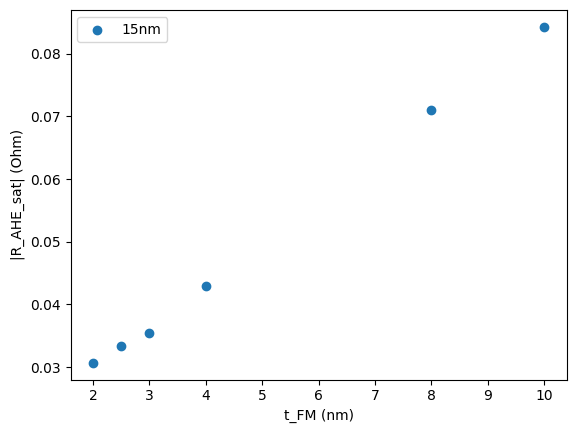

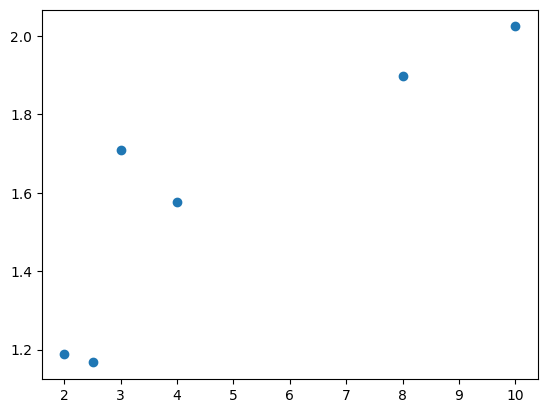

In [2]:
for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group['R_AHE_sat (Ohm)']), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|R_AHE_sat| (Ohm)")
plt.show()

plt.scatter(results_df['t_FM (m)']*1e9, results_df["B_sat_avg (T)"])


In [4]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# ---- USER SETTINGS ----
CURRENT = 1e-4  # current in A (change this!)
OUTPUT_FILE = "AHE_results.csv"

# ----------------------

def load_dat_file(filepath):
    """Load .dat file, skipping metadata lines."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Find header line (starts with 'date')
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith("date"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"No header found in {filepath}")

    # Read into pandas
    df = pd.read_csv(filepath, sep="\t", skiprows=header_idx)

    return df

def analyze_sample(df, sample_name, sample_info, plot=False):
    """Perform AHE-related analysis."""
    # print(df)
    # Clean column names
    df.columns = df.columns.str.strip()
    # print(df.head())
    # Convert relevant columns to numeric
    df["Hy (T)"] = pd.to_numeric(df["Hy (T)"], errors='coerce')
    df["Std_DeltaVolatge"] = pd.to_numeric(df["Std_DeltaVolatge"], errors='coerce')

    # Compute resistance
    current = sample_info.get("I", 0)  # fallback    
    df["R (Ohm)"] = df["Std_DeltaVolatge"] / current

    y_values_div = (df["Std_DeltaVolatge"] * np.sqrt(2)) / 0.0001

    threshold = sample_info["threshold"]

    positive_mask = df["Hy (T)"] >= 0.4
    x_pos = df.loc[positive_mask, "Hy (T)"].to_numpy()
    y_pos = df.loc[positive_mask, "R (Ohm)"].to_numpy()

    # Compute smoothed derivative
    dy_pos = np.abs(np.diff(y_pos))
    window = 5
    dy_pos_smooth = np.convolve(dy_pos, np.ones(window)/window, mode='valid')

    # Find indices where derivative is below threshold
    saturation_indices_pos = np.where(dy_pos_smooth < threshold)[0]

    if len(saturation_indices_pos) == 0:
        # --- fallback: use last N points as "saturated" ---
        print("No saturation index found, using last 5 points as fallback")
        first_sat_index_pos = max(len(x_pos) - 5, 0)  # avoid negative index
    else:
        # Correct offset to map smoothed index back to y_pos
        offset = (window - 1)//2 + 1
        first_sat_index_pos = saturation_indices_pos[0] + offset
        first_sat_index_pos = min(first_sat_index_pos, len(x_pos)-1)  # avoid out-of-bounds

    # Saturation field and mask
    saturation_threshold_B_pos = x_pos[first_sat_index_pos]
    saturation_mask_pos = x_pos >= saturation_threshold_B_pos

    # Mean saturation resistance
    if saturation_mask_pos.any():
        saturation_R_mean_pos = y_pos[saturation_mask_pos].mean()
    else:
        # fallback if mask is empty
        saturation_R_mean_pos = y_pos[-1]

    negative_mask = df["Hy (T)"] <= -0.4
    x_neg = df.loc[negative_mask, "Hy (T)"].to_numpy()
    y_neg = df.loc[negative_mask, "R (Ohm)"].to_numpy()

    # Compute smoothed derivative
    dy_neg = np.abs(np.diff(y_neg))
    window = 5
    dy_neg_smooth = np.convolve(dy_neg, np.ones(window)/window, mode='valid')

    # Find indices where derivative is below threshold
    saturation_indices_neg = np.where(dy_neg_smooth < threshold)[0]

    if len(saturation_indices_neg) == 0:
        print("No saturation index found, using last 5 points as fallback")
        first_sat_index_neg = max(len(x_neg) - 5, 0)
    else:
        offset = (window - 1)//2 + 1
        first_sat_index_neg = saturation_indices_neg[0] + offset
        first_sat_index_neg = min(first_sat_index_neg, len(x_neg)-1)

    # Saturation field and mask (fix: <= for negative side)
    saturation_threshold_B_neg = x_neg[first_sat_index_neg]
    saturation_mask_neg = x_neg <= saturation_threshold_B_neg

    # Mean saturation resistance
    if saturation_mask_neg.any():
        saturation_R_mean_neg = y_neg[saturation_mask_neg].mean()
    else:
        saturation_R_mean_neg = y_neg[-1]
        
    # 出力
    print(f"Positive saturation field: {saturation_threshold_B_pos:.3f} T")
    print(f"Negative saturation field: {saturation_threshold_B_neg:.3f} T")
    print(f"Average resistance at positive field: {saturation_R_mean_pos:.4f} Ω")
    print(f"Average resistance at negative field: {saturation_threshold_B_neg:.4f} Ω")
    if plot: 
        # グラフ描画
        plt.figure(figsize=(12.5, 9.5))
        plt.scatter(df["Hy (T)"], df["R (Ohm)"], color='black', label='Data (Shifted)', s=100, zorder=3)
        
        plt.axvline(saturation_threshold_B_pos, color='green', linestyle=':', linewidth=3, label='Saturation Threshold (+)')
        plt.axvline(saturation_threshold_B_neg, color='blue', linestyle=':', linewidth=3, label='Saturation Threshold (-)')
        
        plt.axhline(saturation_R_mean_pos, color='orange', linestyle='--', linewidth=3, label='Saturation R mean (+)')
        plt.axhline(saturation_R_mean_neg, color='red', linestyle='--', linewidth=3, label='Saturation R mean (-)')
        
        plt.xlabel(r'$B_{\mathrm{ext}}$ (T)', fontsize=54, labelpad=18)
        plt.ylabel(r'$R_{xy}^{\mathrm{AHE}}$ ($\Omega$)', fontsize=54, labelpad=18)
        
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        
        plt.legend(fontsize=18, ncol=2, loc='upper left', bbox_to_anchor=(-0.01, 1.25))
        plt.grid(False)
        plt.tight_layout()
        plt.savefig('saturation_magnetization_out_of_plane_290K.png', dpi=300, format='png')
        plt.title(f"{sample_name}")
    plt.show()


    # ---- Extract key metrics ----
    results = {
        "Sample": sample_name,
        "Label": sample_info["label"],
        "t_FM (m)": sample_info["t_FM"],
        "t_NM (m)": sample_info["t_NM"],
        "Current (A)": current,

        "R0": df["R (Ohm)"][0],
        # Magnetic field properties
        "B_sat_pos (T)": saturation_threshold_B_pos,
        "B_sat_neg (T)": saturation_threshold_B_neg,

        # Resistance properties
        "R_sat_pos (Ohm)": saturation_R_mean_pos,
        "R_sat_neg (Ohm)": saturation_R_mean_neg,

        # Derived quantities (often useful)
        "R_AHE_sat (Ohm)": (saturation_R_mean_pos - saturation_R_mean_neg) / 2,
        "B_sat_avg (T)": (abs(saturation_threshold_B_pos) + abs(saturation_threshold_B_neg)) / 2,

        # Dataset info
        "Num_points": len(df["R (Ohm)"])
    }
    return results


# ---- MAIN LOOP ----

all_results = []

dat_files = glob.glob("*.dat")

thickness_map = {
    "SSN092_AHE": {"I": 1e-3, "t_FM": 2e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0001},
    "SSN093_AHE": {"I": 1e-3, "t_FM": 2.5e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0005},
    "SSN094_AHE": {"I": 1e-3, "t_FM": 3e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0001},
    "SSN095_AHE": {"I": 1e-3, "t_FM": 4e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},
    "DK159_AHE": {"I": 1e-3, "t_FM": 5e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},
    "SSN096_AHE": {"I": 1e-3, "t_FM": 8e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},
    "SSN097_AHE": {"I": 1e-3, "t_FM": 10e-9,"t_NM": 15e-9,"label": "15nm","threshold": 0.0003},

    "SSN098_AHE": {"I": 1e-3, "t_FM": 2e-9,"t_NM": 5e-9,"label": "5nm", "threshold": 0.01},
    "SSN099_AHE": {"I": 1e-3, "t_FM": 2.5e-9,"t_NM": 5e-9,"label": "5nm", "threshold": 0.003},
    "SSN100_AHE": { "I": 1e-3, "t_FM": 3e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.001},
    "SSN101_AHE": {"I": 1e-3, "t_FM": 4e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.0005},
    "DK158_AHE": {"I": 1e-3, "t_FM": 5e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.0005},
    "SSN102_AHE": {"I": 1e-4, "t_FM": 8e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.002},
    "SSN103_AHE": {"I": 1e-4, "t_FM": 10e-9,"t_NM": 5e-9,"label": "5nm","threshold": 0.005},
}

for file in dat_files:
    sample_name = os.path.splitext(os.path.basename(file))[0]

    if sample_name not in thickness_map:
        print(f"Skipping {sample_name}: not in mapping")
        continue

    sample_info = thickness_map[sample_name]
    
    df = load_dat_file(file)
    res = analyze_sample(df, sample_name, sample_info, plot=False)
    all_results.append(res)
    print(f"Processed: {sample_name}")

# Save results
results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_FILE, index=False)
# print(results_df)
print(f"\nResults saved to {OUTPUT_FILE}")

AttributeError: partially initialized module 'pandas' from 'c:\git\MasterProject\venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

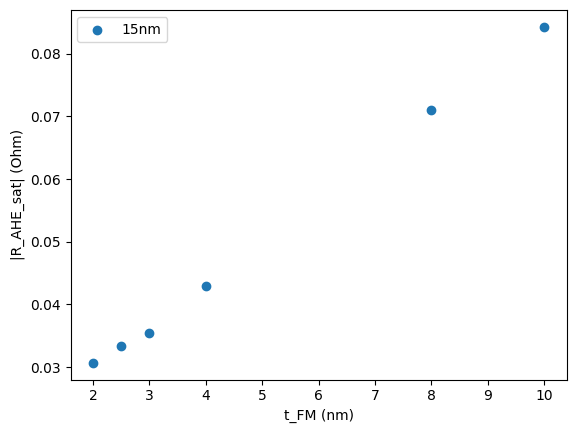

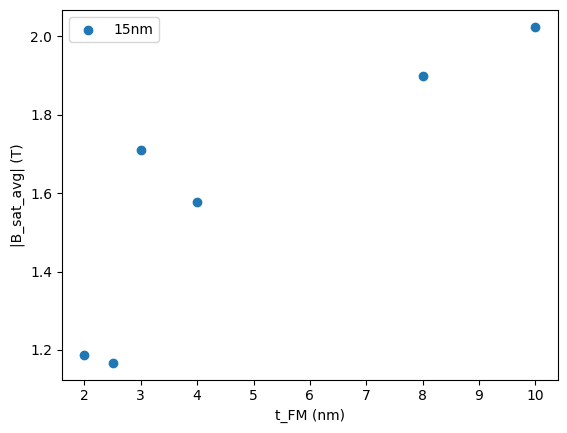

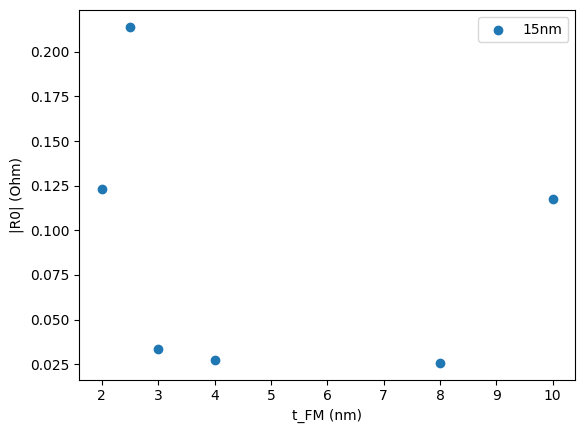

In [30]:
for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group['R_AHE_sat (Ohm)']), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|R_AHE_sat| (Ohm)")
plt.show()


for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group["B_sat_avg (T)"]), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|B_sat_avg| (T)")
plt.show()

for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group["R0"]), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|R0| (Ohm)")
plt.show()

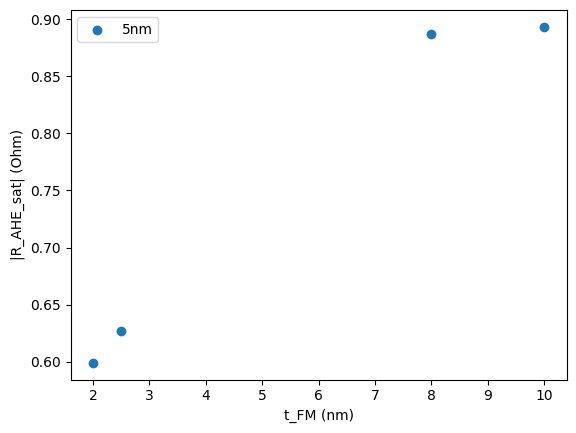

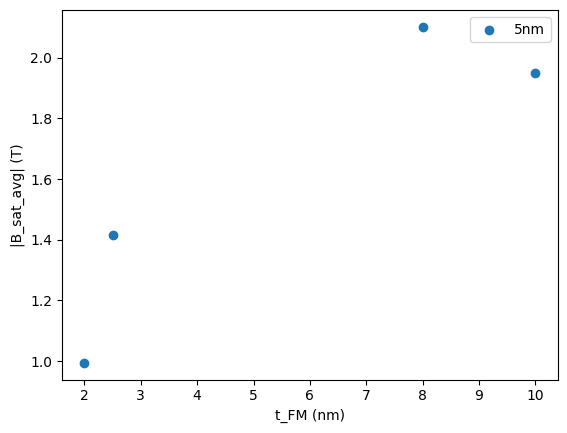

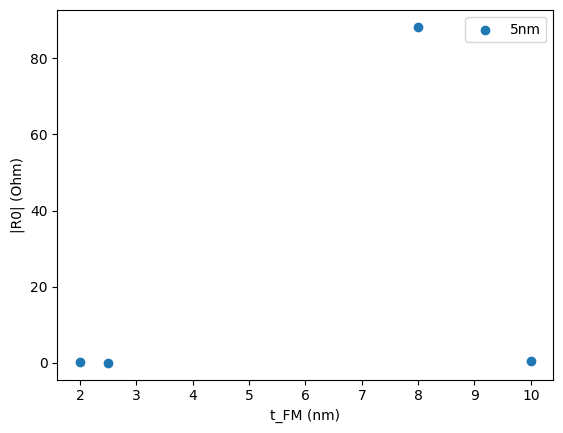

In [27]:
for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group['R_AHE_sat (Ohm)']), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|R_AHE_sat| (Ohm)")
plt.show()


for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group["B_sat_avg (T)"]), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|B_sat_avg| (T)")
plt.show()

for label, group in results_df.groupby("Label"):
    plt.scatter(group['t_FM (m)']*1e9, abs(group["R0"]), label=label)

plt.legend()
plt.xlabel("t_FM (nm)")
plt.ylabel("|R0| (Ohm)")
plt.show()